# Notes
## Target
1. Revenue true / false
## Cleaning
1. No missing values in dataset.
0. Duplicates present - likely errors due to repeated values across specific columns

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Utilities

In [91]:
def adaboost_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    param_grid,
    use_scaler=False,
    use_smote=False,
    random_state=37,
):

    steps = []

    if use_scaler:
        steps.append(('scaler', StandardScaler()))

    if use_smote:
        steps.append(('smote', SMOTE(random_state=random_state)))

    steps.append(('classification', AdaBoostClassifier(random_state=random_state)))

    model = Pipeline(steps=steps)
    gs = GridSearchCV(
        estimator=model, param_grid=param_grid, scoring='recall', cv=5, n_jobs=-1
    )

    gs.fit(X_train, y_train)

    print('=' * 60)
    print(f'Scaler: {use_scaler} | SMOTE: {use_smote}')
    print('Best Params:', gs.best_params_)
    print('Best Recall:', gs.best_score_)

    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test)

    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred, digits=3))

# Data Exploration

In [71]:
# Importing dataset
dataset = pd.read_csv('dataset/online_shoppers_intention.csv')
dataset

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [72]:
dataset.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [73]:
dataset.shape


(12330, 18)

In [74]:
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [75]:
dataset.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [76]:
# No missing values in the dataset
dataset.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [77]:
# Duplicates may be present
dataset.duplicated().sum()


np.int64(125)

In [78]:
# Examine duplicates.
dataset[dataset.duplicated(keep=False)].head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


In [79]:
# Drop the duplicates.
dataset = dataset.drop_duplicates()

In [80]:
# Check for invalid values. Step recommended by ChatGPT
print((dataset[['BounceRates', 'ExitRates', 'SpecialDay']] < 0).sum())
print((dataset[['BounceRates', 'ExitRates', 'SpecialDay']] > 1).sum())
print(
    (
        dataset[
            [
                'Administrative_Duration',
                'Informational_Duration',
                'ProductRelated_Duration',
            ]
        ]
        < 0
    ).sum()
)

BounceRates    0
ExitRates      0
SpecialDay     0
dtype: int64
BounceRates    0
ExitRates      0
SpecialDay     0
dtype: int64
Administrative_Duration    0
Informational_Duration     0
ProductRelated_Duration    0
dtype: int64


In [81]:
# Check for dataset balance. Target value is imbalanced
print(dataset['Revenue'].value_counts(normalize=True))
print(dataset['Revenue'].value_counts())

Revenue
False    0.843671
True     0.156329
Name: proportion, dtype: float64
Revenue
False    10297
True      1908
Name: count, dtype: int64


In [82]:
# PageValues correlates to revenue. People with high PageValues purchase more.
print(dataset.groupby('Revenue')['PageValues'].mean())
print(dataset.groupby('Revenue')['ProductRelated_Duration'].mean())

Revenue
False     1.999985
True     27.264518
Name: PageValues, dtype: float64
Revenue
False    1082.976881
True     1876.209615
Name: ProductRelated_Duration, dtype: float64


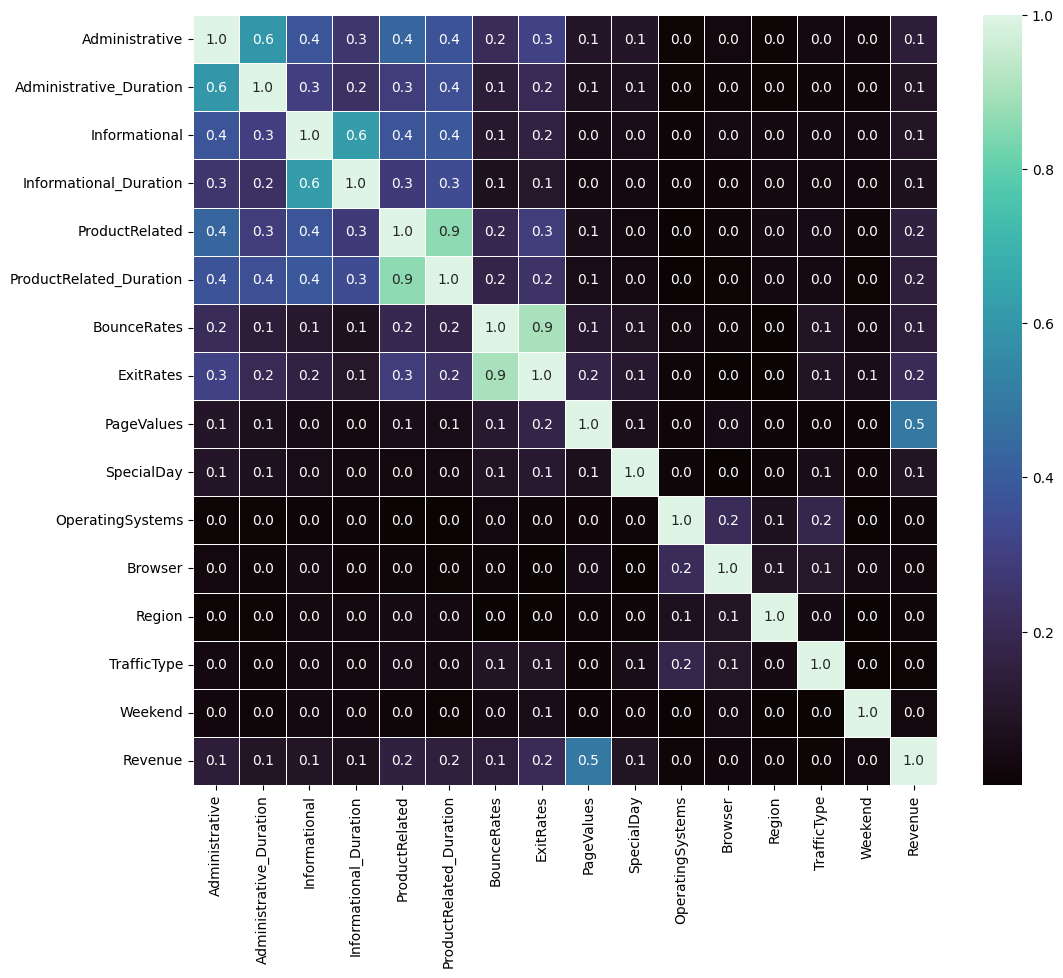

In [83]:
# Examine correlation between values
corr = dataset.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(
    np.abs(corr),
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cmap='mako',
)
plt.show()

In [84]:
dataset.nunique().sort_values()

Revenue                       2
Weekend                       2
VisitorType                   3
SpecialDay                    6
OperatingSystems              8
Region                        9
Month                        10
Browser                      13
Informational                17
TrafficType                  20
Administrative               27
ProductRelated              311
Informational_Duration     1258
BounceRates                1872
PageValues                 2704
Administrative_Duration    3335
ExitRates                  4777
ProductRelated_Duration    9551
dtype: int64

In [85]:
# Converting Bools features into Binary features
dataset['Weekend'] = dataset['Weekend'].map({True: 1, False: 0})
dataset['Revenue'] = dataset['Revenue'].map({True: 1, False: 0})

In [86]:
# Convert categories into numerical features. Drop first used to reduce redundancy and
# correctly represent categorical values. Tree models may handle them as integers, but
# I chose to one hot encode as they are not ordered values.
# Categorical values listed here: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset
final_data_ohe = pd.get_dummies(
    dataset,
    columns=[
        'Month',
        'VisitorType',
        'TrafficType',
        'Region',
        'Browser',
        'OperatingSystems',
    ],
    drop_first=True,
)
final_data_ohe.info()

<class 'pandas.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12205 non-null  int64  
 1   Administrative_Duration        12205 non-null  float64
 2   Informational                  12205 non-null  int64  
 3   Informational_Duration         12205 non-null  float64
 4   ProductRelated                 12205 non-null  int64  
 5   ProductRelated_Duration        12205 non-null  float64
 6   BounceRates                    12205 non-null  float64
 7   ExitRates                      12205 non-null  float64
 8   PageValues                     12205 non-null  float64
 9   SpecialDay                     12205 non-null  float64
 10  Weekend                        12205 non-null  int64  
 11  Revenue                        12205 non-null  int64  
 12  Month_Dec                      12205 non-null  bool   
 13  Mo

In [87]:
final_data_ohe.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser_11,Browser_12,Browser_13,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,False,False,True,False,False,False,False,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,True,False,False,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False


In [88]:
# Remove Revenue from predictive values
X = final_data_ohe.drop('Revenue', axis=1)
y = final_data_ohe['Revenue']

# Split the set into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=37
)

# Ensure they produc similar values
print('Train positive rate:', y_train.mean())
print('Test positive rate:', y_test.mean())
print(X_train.shape, X_test.shape)

Train positive rate: 0.15628840639082342
Test positive rate: 0.15649324047521507
(9764, 68) (2441, 68)


In [ ]:
# model = Pipeline(steps=[
#     ("balancing", SMOTE(random_state=17)),
#     ("classification", RandomForestClassifier(
#         criterion="entropy",
#         max_features="sqrt",
#         random_state=17,
#         n_jobs=-1
#     ))
# ])


# Parameters understood from https://www.upgrad.com/blog/random-forest-hyperparameter-tuning/
# Refined through mutliple runs
# grid_param = {
#     "classification__max_depth": [4, 5, 6],
#     "classification__min_samples_leaf": [2, 3, 5],
#     "classification__min_samples_split": [2, 3, 4],
#     "classification__n_estimators": [150, 175, 200],

# }

In [ ]:
grid_param = {
    'classification__estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=17),
        DecisionTreeClassifier(max_depth=2, random_state=17),
    ],
    'classification__n_estimators': [20, 50, 100],
    'classification__learning_rate': [0.005, 0.01, 0.025, 0.05],
}

In [ ]:
adaboost_experiment(X_train, X_test, y_train, y_test, grid_param)

Scaler: False | SMOTE: False
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=17), 'classification__learning_rate': 0.005, 'classification__n_estimators': 20}
Best Recall: 0.8027686703096538
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441



In [ ]:
adaboost_experiment(X_train, X_test, y_train, y_test, grid_param, use_smote=True)

Scaler: False | SMOTE: True
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=17), 'classification__learning_rate': 0.005, 'classification__n_estimators': 20}
Best Recall: 0.8080145719489981
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441



In [ ]:
adaboost_experiment(X_train, X_test, y_train, y_test, grid_param, use_scaler=True)

Scaler: True | SMOTE: False
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=17), 'classification__learning_rate': 0.005, 'classification__n_estimators': 20}
Best Recall: 0.8027686703096538
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441



In [ ]:
adaboost_experiment(
    X_train, X_test, y_train, y_test, grid_param, use_smote=True, use_scaler=True
)

Scaler: True | SMOTE: True
Best Params: {'classification__estimator': DecisionTreeClassifier(max_depth=1, random_state=17), 'classification__learning_rate': 0.005, 'classification__n_estimators': 20}
Best Recall: 0.8080145719489981
Confusion Matrix:
[[1819  240]
 [  77  305]]
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.883     0.920      2059
           1      0.560     0.798     0.658       382

    accuracy                          0.870      2441
   macro avg      0.760     0.841     0.789      2441
weighted avg      0.897     0.870     0.879      2441

